In [155]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('..')
import plot_settings
importlib.reload(sim_PyBaMM)
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver2
importlib.reload(exp_pybamm_ver2)

<module 'exp_pybamm_ver2' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../exp_pybamm_ver2.py'>

In [156]:
from neuralop.models import FNO

In [157]:
t,_, I, c = exp_pybamm_ver2.get_npc_xavg()
print(c.shape)

(22, 1000)


In [158]:
def gen_data_NO(batches):
    I = np.zeros((batches,1,1000))
    c = np.zeros((batches,22,1000))
    for i in trange(batches):
        t,_, I[i,0,:], c[i,...] = exp_pybamm_ver2.get_npc_xavg()
    return I, c, t

In [159]:
I ,c, t = gen_data_NO(2)





100%|██████████| 2/2 [00:04<00:00,  2.28s/it]


In [160]:
print(t[-1])

7200.0


In [161]:
def grid_gen(xlim, ylim, size):  
    x_size =  size[0]; y_size = size[1]

    x = np.linspace(xlim[0], xlim[1], int(x_size))
    y = np.linspace(ylim[0], ylim[1], int(y_size))
    X, Y = np.meshgrid(x, y)
    return X, Y

In [162]:
T, R = grid_gen([0,int(t[-1])],[0,10], size=[1000,22])

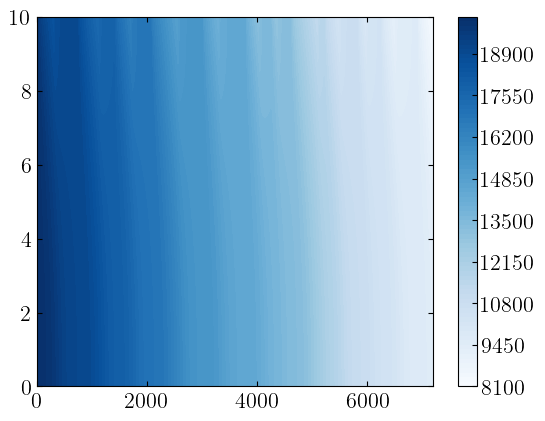

In [163]:
plt.contourf(T,R,c[0,...],levels = 100, cmap='Blues')
plt.colorbar()

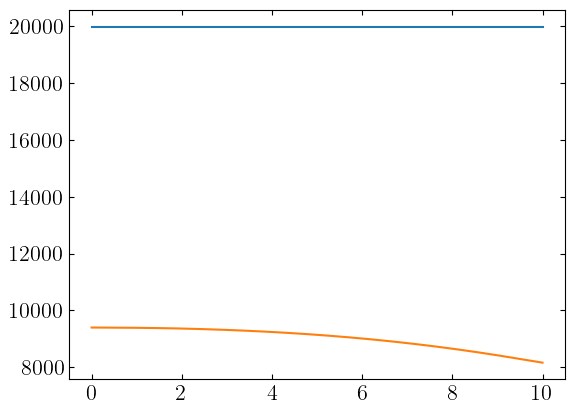

In [164]:
t0 = 0; t1 = 999
plt.plot(np.linspace(0,10,len(c[0,:,t0])), c[0,:,t0])
plt.plot(np.linspace(0,10,len(c[0,:,t1])), c[0,:,t1])

In [165]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

In [166]:


# np.savez('data_NO/I.npz',np.vstack((I,I_gen)))
# np.savez('data_NO/V.npz',np.vstack((V,V_gen)))

In [167]:
I = np.load('data_NO/I.npz')['arr_0']
V = np.load('data_NO/V.npz')['arr_0']



test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; V_test = V[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; V_train = V[int(test_size * len(I)):,:,:]

In [168]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(32,),         
    hidden_channels=128, 
    in_channels=1,      
    out_channels=1,     
)

In [169]:
# from torch.utils.data import DataLoader, TensorDataset

# N, T = 1024, 64

# u = np.zeros((N, T,1))
# y = np.zeros((N, T,1))
# for i in trange(N):
#     w = random.uniform(0.5, 2.0)
#     u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
#     y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


# print(u.shape, y.shape  )

# dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
#                         torch.tensor(y, dtype=torch.float32))

# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# u_batch, y_batch = next(iter(loader))
# print(u_batch.shape)  # should be [32, 64, 1]


In [170]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(V, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()

torch.Size([32, 1, 1000])


In [171]:

# epochs = 50
# tol = 2.5e-4
# for epoch in range(epochs):
#     nb = 0 
#     loss_sum = 0
#     start_b = time.perf_counter()
#     for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
#         y_pred = model(u_batch)
#         loss = loss_fn(y_pred, y_batch)
#         loss_sum += loss.item()
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         nb += 1
#     end_b = time.perf_counter()
#     ETA = (end_b-start_b)*(epochs-epoch-1)
#     if loss_sum / nb < tol:
#         print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
#         break
#     print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    

In [172]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
            y_pred = model(u_batch)
            loss = loss_fn(y_pred, y_batch)
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [173]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 2.8800 ETA: 11:29
Epoch 2 average loss: 0.7038 ETA: 11:26
Epoch 3 average loss: 0.2877 ETA: 10:51
Epoch 4 average loss: 0.0959 ETA: 10:54
Epoch 5 average loss: 0.0417 ETA: 12:39
Epoch 6 average loss: 0.0195 ETA: 15:25
Epoch 7 average loss: 0.0103 ETA: 12:41
Epoch 8 average loss: 0.0053 ETA: 9:57
Epoch 9 average loss: 0.0029 ETA: 9:31
Epoch 10 average loss: 0.0017 ETA: 9:14
Epoch 11 average loss: 0.0011 ETA: 8:48
Epoch 12 average loss: 0.0008 ETA: 8:50
Epoch 13 average loss: 0.0006 ETA: 9:40
Epoch 14 average loss: 0.0005 ETA: 8:47
Epoch 15 average loss: 0.0004 ETA: 8:14
Epoch 16 average loss: 0.0004 ETA: 8:04
Epoch 17 average loss: 0.0003 ETA: 7:41
Epoch 18 average loss: 0.0003 ETA: 7:46
Epoch 19 average loss: 0.0003 ETA: 7:54
Epoch 20 average loss: 0.0003 ETA: 7:43
Epoch 21 average loss: 0.0002 Time: 7:05 - Early stopping


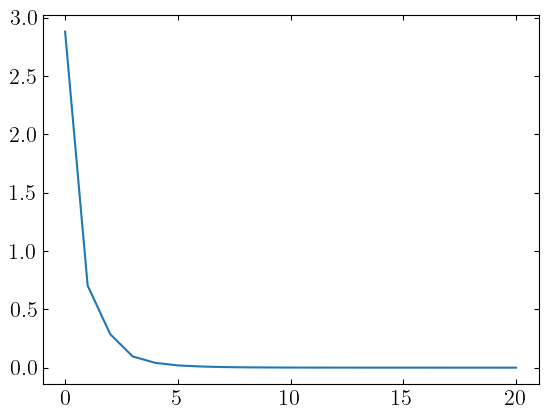

In [174]:
plt.plot(history['loss'])

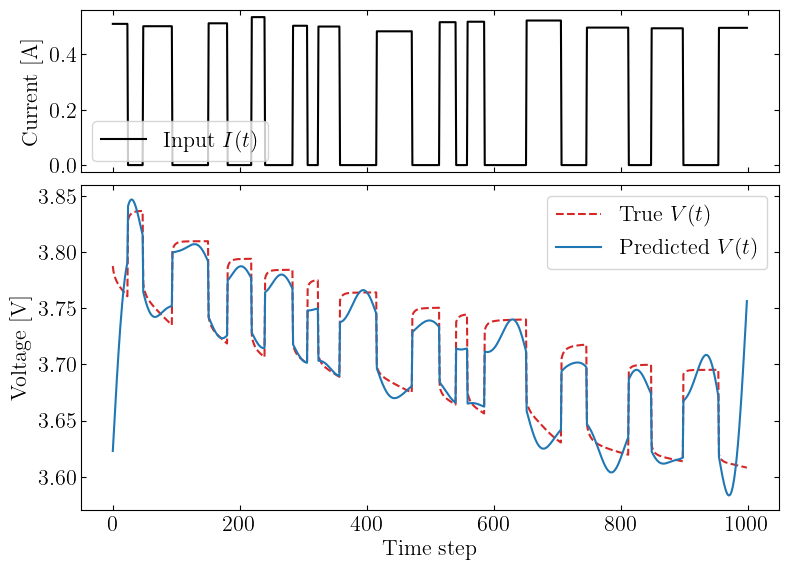

In [175]:
test = 17
i = I_test[test,0,:].reshape(1, 1, 1000) 
v = V_test[test,0,:].reshape(1, 1, 1000)

#print(i.shape, v.shape)
y_pred = model(torch.tensor(i, dtype=torch.float32))
f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
f.subplots_adjust(hspace=0.05)

ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax[1].plot(y_pred[0,0,:].detach().numpy(), label='Predicted $V(t)$', color='tab:blue')
ax[1].legend()
ax[0].legend()
ax[1].set_xlabel('Time step')
ax[0].set_ylabel('Current [A]')
ax[1].set_ylabel('Voltage [V]')
#plt.savefig('figs_NO/FNO_pred.pdf', bbox_inches='tight')
plt.show()

In [176]:
T = 1000

u_test = np.zeros((1, 1,T))
y_test = np.zeros((1, 1,T))
w_test =  30# This is in the training range (0.5 to 2.0)

u_test[0,0,:] = np.sin(w_test * np.linspace(0, 3.14, T))  # w=1.5 is in the training range
y_test[0,0,:] = w_test * np.cos(w_test * np.linspace(0, 3.14, T))

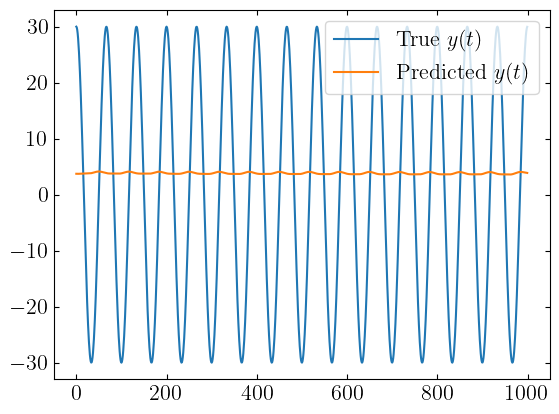

In [177]:
y_pred = model(torch.tensor(u_test, dtype=torch.float32))
plt.plot(y_test[0,0,:], label='True $y(t)$')
plt.plot(y_pred[0,0,:].detach().numpy(), label='Predicted $y(t)$')
plt.legend()
plt.show()